In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '../../src')
from deploy_policy_mix import PolicyEvaluatorMix as PolicyEvaluator
import yaml
import utils
import matplotlib

# ── E_mix rejection table (replaces the log-linear approval test) ──
import yaml as _yaml
from rejection_mix import build_rejection_table_np as _build_rej_tbl_mix
with open('../../config/fiducial_mix.yaml') as _f_cfg_mix:
    _cfg_mix = _yaml.safe_load(_f_cfg_mix)
_REJ_TBL_GLOBAL = _build_rej_tbl_mix(
    (int(_cfg_mix['T']) + 1) * int(_cfg_mix['n_max']),
    float(_cfg_mix['kappa']), float(_cfg_mix['theta_b']),
)


Loading policy from: ../../outputs/fiducial_mix/mdp_output/mdp_mix_results_eps_0.500_T_3_nmax_200_alpha_1.0_beta_1.0_thetab_0.5.pt
P(approval | α₀=1.0, β₀=1.0, l=0) = 0.4314
E[total cost | approved, α₀=1.0, β₀=1.0, l=0] = 29.9064


<Figure size 640x480 with 0 Axes>

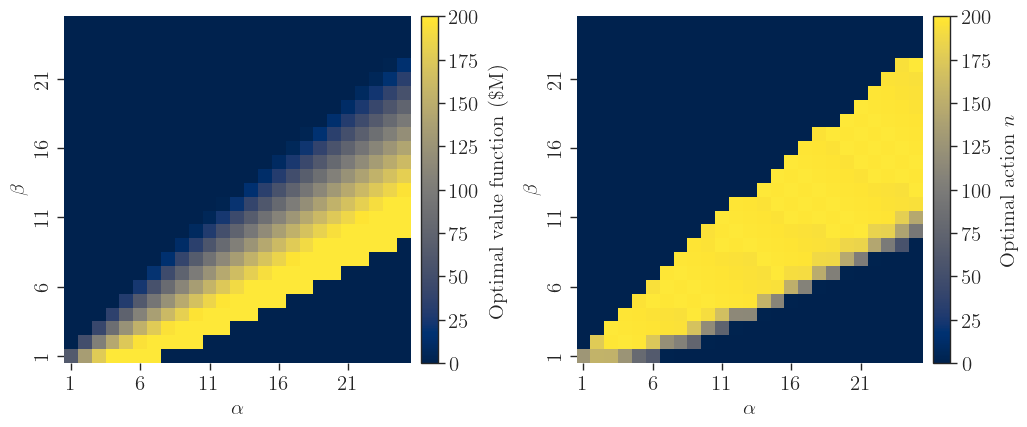

<Figure size 640x480 with 0 Axes>

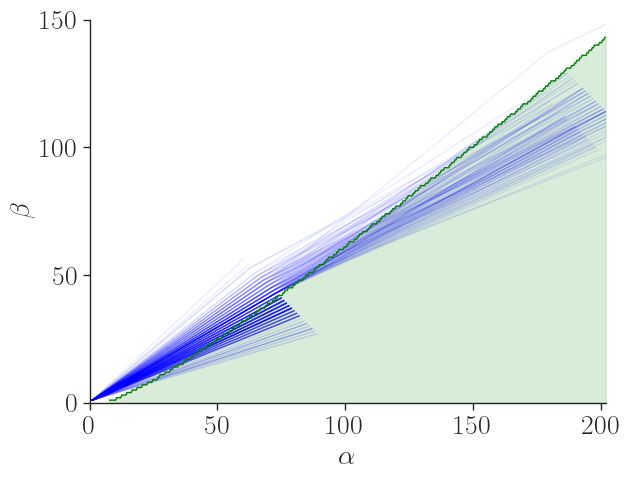

Policy evaluation under θ* = 0.65, ε = 0.5
  P(approval)              = 0.9925  (198,497 / 200,000)
  E[total cost | approved] = 79.6713
 Agent utility            = 198.2336


In [4]:

from mpl_toolkits.axes_grid1 import make_axes_locatable


def plot_belief_space(file_path, l_to_plot=1, tick_step=2, belief_range=10):



    # Load data
    data = torch.load(file_path, weights_only=False)


    # Print initial-state summary statistics
    p_approval = data['P_approval'][0][0, 0]
    a_initial  = data['A'][0][0, 0]
    params = data.get('params', {})
    alpha_0 = params.get('alpha_0', 1.0)
    beta_0 = params.get('beta_0', 1.0)
    n_max = params.get('n_max', 150)
    print(f"P(approval | α₀={alpha_0}, β₀={beta_0}, l=0) = {p_approval:.4f}")
    print(f"E[total cost | approved, α₀={alpha_0}, β₀={beta_0}, l=0] = {a_initial:.4f}")

    # Grid data for the chosen time step
    v_grid = data['V_eps'][l_to_plot]
    p_grid = data['Policy'][l_to_plot]

    # N is the cumulative number of trials (the first dimension of our saved grid)
    max_N = v_grid.shape[0] - 1

    # The range of possible alpha and beta values given max_N
    # alpha can go from alpha_0 to alpha_0 + max_N
    # beta can go from beta_0 to beta_0 + max_N
    alpha_range = np.arange(alpha_0, alpha_0 + max_N + 1)
    beta_range = np.arange(beta_0, beta_0 + max_N + 1)

    # Create the (alpha, beta) visualization grid
    v_belief = np.full((len(beta_range), len(alpha_range)), np.nan)
    p_belief = np.full((len(beta_range), len(alpha_range)), np.nan)

    # Map each (N, X) state in the solver to its (alpha, beta) coordinates
    for n in range(v_grid.shape[0]):
        for x in range(v_grid.shape[1]):
            if x > n: continue # Impossible state

            # Belief update: alpha = alpha_0 + successes, beta = beta_0 + failures
            curr_alpha = alpha_0 + x
            curr_beta = beta_0 + (n - x)

            # Find the index in our visualization grid
            a_idx = int(curr_alpha - alpha_0)
            b_idx = int(curr_beta - beta_0)

            v_belief[b_idx, a_idx] = v_grid[n, x]
            p_belief[b_idx, a_idx] = p_grid[n, x]


    # Plotting

    plt.clf()
    sns.set_theme(context='paper', style='ticks', font_scale=1)
    width_pt = 750
    palette = sns.color_palette('icefire', 3)

    utils.latexify()

    fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=1)
    fig, ax = plt.subplots(1,2, figsize=(fig_width, fig_height))

    #plot only the first belief_range alpha and beta values
    alpha_range = alpha_range[:belief_range]
    beta_range = beta_range[:belief_range]
    v_belief = v_belief[:len(beta_range), :len(alpha_range)]
    p_belief = p_belief[:len(beta_range), :len(alpha_range)]
    # Define ticks
    x_ticks = np.arange(0, len(alpha_range), tick_step)
    y_ticks = np.arange(0, len(beta_range), tick_step)
    x_labels = alpha_range[x_ticks].astype(int)
    y_labels = beta_range[y_ticks].astype(int)

    # Plot Value Function (no built-in colorbar — we add our own)
    #v_norm = matplotlib.colors.Normalize(vmin=0, vmax=np.nanmax(v_belief))
    v_norm = matplotlib.colors.Normalize(vmin=0, vmax=200)
    sns.heatmap(v_belief, ax=ax[0], cmap='cividis', mask=np.isnan(v_belief), norm=v_norm, square=True, cbar=False)
    ax[0].set_xticks(x_ticks + 0.5); ax[0].set_xticklabels(x_labels, fontsize=15)
    ax[0].set_yticks(y_ticks + 0.5); ax[0].set_yticklabels(y_labels, fontsize=15)
    ax[0].set_xlabel("$\\alpha$", fontsize=15); ax[0].set_ylabel("$\\beta$", fontsize=15)
    ax[0].invert_yaxis()

    divider0 = make_axes_locatable(ax[0])
    cax0 = divider0.append_axes("right", size="5%", pad=0.1)
    sm_v = matplotlib.cm.ScalarMappable(norm=v_norm, cmap='cividis')
    sm_v.set_array([])
    cbar_v = fig.colorbar(sm_v, cax=cax0)
    cbar_v.set_label(r'Optimal value function (\$M)', rotation=90, labelpad=5, fontsize=15)
    cbar_v.set_ticks(np.arange(0, 201, 25))
    cbar_v.ax.tick_params(labelsize=15)

    # Plot Policy
    norm = matplotlib.colors.Normalize(vmin=0, vmax=n_max)
    sns.heatmap(p_belief, ax=ax[1], cmap='cividis', mask=np.isnan(p_belief), norm=norm, square=True, cbar=False)
    ax[1].set_xticks(x_ticks + 0.5); ax[1].set_xticklabels(x_labels, fontsize=15)
    ax[1].set_yticks(y_ticks + 0.5); ax[1].set_yticklabels(y_labels, fontsize=15)
    ax[1].set_xlabel("$\\alpha$", fontsize=15); ax[1].set_ylabel("$\\beta$", fontsize=15)
    ax[1].invert_yaxis()

    divider1 = make_axes_locatable(ax[1])
    cax1 = divider1.append_axes("right", size="5%", pad=0.1)
    cbar_p = fig.colorbar(ax[1].collections[0], cax=cax1)
    cbar_p.set_label('Optimal action $n$', rotation=90, labelpad=5, fontsize=15)
    cbar_p.set_ticks(np.arange(0, 201, 25))
    cbar_p.ax.tick_params(labelsize=15)

    #Remove gridlines
    for a in ax:
        a.grid(False)

    plt.tight_layout()
    plt.show()
    fig.savefig('../../figures/fiducial_mix/mdp_output/belief_space.pdf', format='pdf', bbox_inches='tight')






def plot_belief_trajectories(results, evaluator, max_paths=300):
    """
    Plots belief trajectories (alpha, beta) in the plane.
    Fully standardized version: invariant across theta_star.
    """

    belief_paths = results['belief_paths']

    plt.clf()
    sns.set_theme(context='paper', style='ticks', font_scale=1)

    utils.latexify()

    # ----------------------------
    # FIXED AXIS RANGE
    # ----------------------------
    alpha_0 = evaluator.alpha_0
    beta_0  = evaluator.beta_0

    lower = 0
    x_upper = alpha_0 + beta_0 + evaluator.n_max
    y_upper = 150

    # Scale figure height proportionally to the y/x ratio
    fig_width = 6
    fig_height = fig_width * (y_upper - lower) / (x_upper - lower)
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height), dpi=100)

    ax.set_xlim(lower, x_upper)
    ax.set_ylim(lower, y_upper)
    ax.set_aspect('equal', adjustable='box')
    ax.set_autoscale_on(False)

    # ----------------------------
    # PLOT TRAJECTORIES
    # ----------------------------
    paths_to_plot = belief_paths[:max_paths]

    for path in paths_to_plot:
        alphas = [ab[0] for ab in path]
        betas  = [ab[1] for ab in path]

        ax.plot(
            alphas,
            betas,
            color='blue',
            alpha=0.08,
            linewidth=1,
            clip_on=True
        )

    # ----------------------------
    # BOUNDARY CURVE
    # ----------------------------

    alpha_vals = np.linspace(lower, x_upper, 500)

    beta_boundary = np.full_like(alpha_vals, np.nan, dtype=float)
    _max_N_bnd = _REJ_TBL_GLOBAL.shape[0] - 1
    for _i_a, _a_v in enumerate(alpha_vals):
        _X = int(round(_a_v - alpha_0))
        if _X < 0 or _X > _max_N_bnd:
            continue
        _col = np.where(_REJ_TBL_GLOBAL[:, _X])[0]
        _col = _col[_col >= _X]
        if len(_col) == 0:
            continue
        _N_max = int(_col.max())
        beta_boundary[_i_a] = beta_0 + (_N_max - _X)

    ax.plot(alpha_vals, beta_boundary, color='green', linewidth=1)

    ax.fill_between(
        alpha_vals,
        beta_boundary,
        lower,
        where=(beta_boundary >= lower),
        color='green',
        alpha=0.15
    )

    # ----------------------------
    # LABELS + GRID
    # ----------------------------
    ax.set_xlabel(r'$\alpha$', fontsize=20)
    ax.set_ylabel(r'$\beta$', fontsize=20)
    sns.despine()
    tick_step = 50
    x_ticks = np.arange(lower, x_upper + 1, tick_step)
    y_ticks = np.arange(lower, y_upper + 1, tick_step)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_xticklabels(x_ticks.astype(int), fontsize=20)
    ax.set_yticklabels(y_ticks.astype(int), fontsize=20)

    # ----------------------------
    # FIXED MARGINS (NO TIGHT_LAYOUT)
    # ----------------------------
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        bottom=0.12,
        top=0.98
    )

    plt.show()

    # ----------------------------
    # SAVE (DETERMINISTIC OUTPUT)
    # ----------------------------
    fig.savefig(
        f'../../figures/fiducial_mix/mdp_output/belief_space_trajectories_{theta_star}.pdf',
        format='pdf',
        bbox_inches='tight'
    )



# ── Configure these ────────────────────────────────────────────────────────────
config_path = '../../config/fiducial_mix.yaml'
policy_path = '../../outputs/fiducial_mix/mdp_output/mdp_mix_results_eps_0.500_T_3_nmax_200_alpha_1.0_beta_1.0_thetab_0.5.pt'
theta_star  = 0.65    # true efficacy θ*
n_episodes  = 200_000
# ───────────────────────────────────────────────────────────────────────────────
with open(config_path) as f:
    config = yaml.safe_load(f)

evaluator = PolicyEvaluator(
    rho_A       = config['rho_A'],
    T           = config['T'],
    n_max       = config['n_max'],
    c0          = config['c0'],
    c1          = config['c1'],
    epsilon     = config['epsilon'],
    kappa       = config['kappa'],
    theta_b     = config['theta_b'],
    alpha_0     = config['alpha_0'],
    beta_0      = config['beta_0'],
    theta_star  = theta_star,
    policy_path = policy_path,
    n_episodes  = n_episodes,
)
results = evaluator.evaluate()




plot_belief_space(policy_path, l_to_plot=1, tick_step=5, belief_range=25)
plot_belief_trajectories(results, evaluator)
print(f"Policy evaluation under θ* = {results['theta_star']}, ε = {results['epsilon']}")
print(f"  P(approval)              = {results['p_approval']:.4f}  ({results['n_approved']:,} / {results['n_episodes']:,})")
print(f"  E[total cost | approved] = {results['e_cost_given_approval']:.4f}")
print(f" Agent utility            = {results['agent_utility']:.4f}")


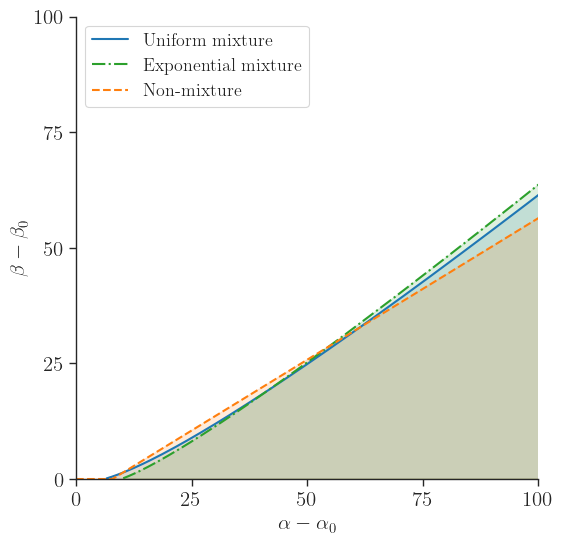

In [14]:
# ── Rejection regions: non-mixture vs mixture e-value in the (α, β) plane ────
from scipy.integrate import quad
from scipy.optimize import brentq
from rejection_mix import log_E_mix as _log_E_mix_vec

alpha_0 = config['alpha_0']
beta_0  = config['beta_0']
kappa   = config['kappa']
theta_b = config['theta_b']
n_max   = config['n_max']
T       = config['T']

log_kappa_inv = np.log(1.0 / kappa)
log_term      = np.log(1.0 + theta_b * (np.e - 1.0))

# ── Axis limits ──────────────────────────────────────────────────────────────
max_N_search = (T + 1) * n_max
alpha_upper  = alpha_0 + T * n_max
beta_upper   = beta_0  + T * n_max
alpha_vals   = np.linspace(alpha_0, alpha_upper, 1000)

# ── 1) Non-mixture (log-linear) boundary ─────────────────────────────────────
#   Rejection when: X - N * log_term >= log(1/κ)
#   In (α,β): β ≤ β₀ + (α - α₀)*(1/log_term - 1) - log(1/κ)/log_term
X_vals = alpha_vals - alpha_0
beta_boundary_std = beta_0 + X_vals * (1.0 / log_term - 1.0) - log_kappa_inv / log_term

# ── Helper: continuous log_E_mix (scalar wrapper) ────────────────────────────
def _log_E_mix_scalar(N, X):
    """log E_mix for real-valued (N, X) — wraps the vectorised version."""
    return float(_log_E_mix_vec(np.array([N]), np.array([X]), theta_b)[0])

# ── 2) Mixture (uniform) boundary via root-finding ─────────────────
beta_boundary_mix = np.full(len(alpha_vals), np.nan)
for _i, _a in enumerate(alpha_vals):
    _X = _a - alpha_0
    if _X < 0.5:
        continue
    # Check if N = X already fails to reject
    if _log_E_mix_scalar(_X, _X) < log_kappa_inv:
        continue
    # Check if N = max_N_search still rejects (boundary beyond our range)
    if _log_E_mix_scalar(max_N_search, _X) >= log_kappa_inv:
        beta_boundary_mix[_i] = beta_0 + (max_N_search - _X)
        continue
    # Find N* where log_E_mix(N*, X) = log(1/κ)
    N_star = brentq(lambda N: _log_E_mix_scalar(N, _X) - log_kappa_inv,
                    _X, max_N_search, xtol=0.01)
    beta_boundary_mix[_i] = beta_0 + (N_star - _X)

# ── 3) Mixture (exponential decay) boundary via root-finding  ────────
#   w(θ) = λ exp(-λ(θ - θ_b)) / (1 - exp(-λ(1 - θ_b)))  on [θ_b, 1]
lam_exp = 10.0   # decay rate; larger means more mass near θ_b

_log_tb   = np.log(theta_b)
_log_1mtb = np.log(1.0 - theta_b)
_exp_norm = 1.0 - np.exp(-lam_exp * (1.0 - theta_b))

def _log_E_exp(N, X):
    """Log exponential-mixture e-value for real-valued (N, X)."""
    if X > N or X < 0 or N < 0:
        return -np.inf
    def integrand(theta):
        return np.exp(X * np.log(theta) + (N - X) * np.log(1.0 - theta)
                      - lam_exp * (theta - theta_b))
    integral, _ = quad(integrand, theta_b, 1.0, limit=100)
    if integral <= 0:
        return -np.inf
    log_num = np.log(lam_exp) + np.log(integral) - np.log(_exp_norm)
    log_den = X * _log_tb + (N - X) * _log_1mtb
    return log_num - log_den

beta_boundary_exp = np.full(len(alpha_vals), np.nan)
for _i, _a in enumerate(alpha_vals):
    _X = _a - alpha_0
    if _X < 0.5:
        continue
    if _log_E_exp(_X, _X) < log_kappa_inv:
        continue
    if _log_E_exp(max_N_search, _X) >= log_kappa_inv:
        beta_boundary_exp[_i] = beta_0 + (max_N_search - _X)
        continue
    N_star = brentq(lambda N: _log_E_exp(N, _X) - log_kappa_inv,
                    _X, max_N_search, xtol=0.01)
    beta_boundary_exp[_i] = beta_0 + (N_star - _X)

# ── Shift to (α - α₀, β - β₀) coordinates ────────────────────────────────────
alpha_vals_shifted    = alpha_vals - alpha_0
beta_boundary_mix_sh  = beta_boundary_mix - beta_0
beta_boundary_exp_sh  = beta_boundary_exp - beta_0
beta_boundary_std_sh  = beta_boundary_std - beta_0

# ── Plot ─────────────────────────────────────────────────────────────────────
sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 750
fig_width, _ = utils.get_fig_dim(width_pt, fraction=0.55)
fig, ax = plt.subplots(figsize=(fig_width, fig_width))

palette = sns.color_palette('tab10')

# Mixture (uniform) rejection region
ax.fill_between(alpha_vals_shifted, 0, beta_boundary_mix_sh,
                where=~np.isnan(beta_boundary_mix_sh),
                color=palette[0], alpha=0.15)
ax.plot(alpha_vals_shifted, beta_boundary_mix_sh, color=palette[0], lw=1.5,
        label=r'Uniform mixture')



# Exponential mixture rejection region
ax.fill_between(alpha_vals_shifted, 0, beta_boundary_exp_sh,
                where=~np.isnan(beta_boundary_exp_sh),
                color=palette[2], alpha=0.15)
ax.plot(alpha_vals_shifted, beta_boundary_exp_sh, color=palette[2], lw=1.5, ls='-.',
        label=rf'Exponential mixture')

# Non-mixture rejection region
beta_std_clipped = np.clip(beta_boundary_std_sh, 0, None)
ax.fill_between(alpha_vals_shifted, 0, beta_std_clipped,
                color=palette[1], alpha=0.15)
ax.plot(alpha_vals_shifted, beta_std_clipped, color=palette[1], lw=1.5, ls='--',
        label=r'Non-mixture')

# ── Formatting ───────────────────────────────────────────────────────────────
ax.set_xlim(0, 50)
ax.set_ylim(0, 50)
ax.set_aspect('equal', adjustable='box')
ax.set_box_aspect(1)

ax.set_xticks([0, 25, 50, 75, 100])
ax.set_yticks([0, 25, 50, 75, 100])
ax.tick_params(axis='both', labelsize=15)

ax.set_xlabel(r'$\alpha - \alpha_0$', fontsize=15)
ax.set_ylabel(r'$\beta - \beta_0$', fontsize=15)
ax.legend(fontsize=13, loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

import os
fig_dir = '../../figures/fiducial_mix/mdp_output'
os.makedirs(fig_dir, exist_ok=True)
fig.savefig(os.path.join(fig_dir, 'rejection_regions_comparison.pdf'),
            format='pdf')


# Plot Q values

log(1 + theta_b(e-1)) = 0.620115
Expected oscillation period = 1 / 0.620115 approx 1.61 samples


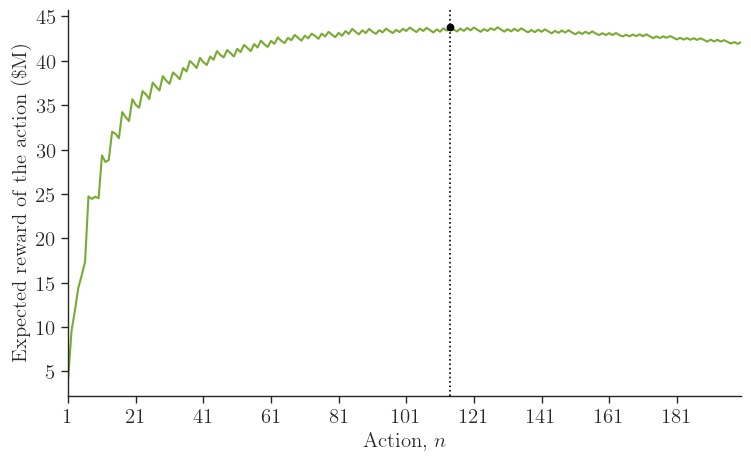

In [4]:
def plot_Q_values(file_path, state, l_to_plot=1, tick_step=5):
    """
    Plot Q(n) for n=1..n_max at a specified (alpha, beta) belief state.

    Parameters
    ----------
    file_path : str
        Path to the saved .pt MDP results file.
    state : tuple of (alpha, beta)
        Belief state to plot, e.g. (3, 10).
    l_to_plot : int
        Time step at which to evaluate Q(n). States reachable at l have N <= l*n_max.
    tick_step : int
        Step for x-axis ticks.
    """
    import math

    data   = torch.load(file_path, weights_only=False)
    params = data['params']
    alpha_0 = params['alpha_0']
    beta_0  = params['beta_0']
    kappa   = params['kappa']
    theta_b = params['theta_b']
    rho_A   = params['rho_A']
    epsilon = params['epsilon']
    c0      = params['c0']
    c1      = params['c1']
    T       = params['T']
    n_max   = params['n_max']

    log_kappa_inv = np.log(1.0 / kappa)
    log_term      = np.log(1.0 + theta_b * (np.e - 1.0))
    period        = 1.0 / log_term

    print(f"log(1 + theta_b(e-1)) = {log_term:.6f}")
    print(f"Expected oscillation period = 1 / {log_term:.6f} approx {period:.2f} samples")

    def check_rejection_np(N, X):
        return bool(_REJ_TBL_GLOBAL[int(N), int(X)])

    def bb_pmf(x_arr, n, alpha, beta):
        x = x_arr.astype(float)
        lp = (
            math.lgamma(n + 1)
            - np.array([math.lgamma(xi + 1) for xi in x])
            - np.array([math.lgamma(n - xi + 1) for xi in x])
            + np.array([math.lgamma(xi + alpha) for xi in x])
            + np.array([math.lgamma(n - xi + beta) for xi in x])
            - math.lgamma(n + alpha + beta)
            + math.lgamma(alpha + beta) - math.lgamma(alpha) - math.lgamma(beta)
        )
        return np.exp(lp)

    alpha_s, beta_s = state
    X = int(alpha_s - alpha_0)
    N = X + int(beta_s - beta_0)

    max_N_global = T * n_max
    V_next = data['V_eps'][l_to_plot + 1] if l_to_plot < T else np.zeros((max_N_global + 1, max_N_global + 1))
    actions = np.arange(1, n_max + 1)

    sns.set_theme(context='paper', style='ticks', font_scale=1)
    palette = sns.color_palette('husl', 10)
    utils.latexify()
    width_pt = 1000
    fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    ax.set_xlim(1, n_max)
    ax.set_xticks(np.arange(1, n_max + 1, tick_step))
    ax.set_xlabel(r"Action, $n$", fontsize=15)
    ax.set_ylabel(r"Expected reward of the action (\$M)", fontsize=15)

    #Set x axis ticks every 20 actions
    ax.set_xticks(np.arange(1, n_max + 1, 20))
    ax.set_xticklabels([f'{x}' for x in ax.get_xticks()], fontsize=15)

    #set ylabels ticks fontsize
    ax.tick_params(axis='y', labelsize=15)

    if X < 0 or N < 0 or X > N:
        ax.set_title(r"$\alpha$" + f"={alpha_s}, " + r"$\beta$" + f"={beta_s} -- invalid state")
        plt.tight_layout()
        plt.show()
        return

    if N > l_to_plot * n_max:
        ax.set_title(
            r"$\alpha$" + f"={alpha_s}, " + r"$\beta$" + f"={beta_s} -- unreachable at $l$={l_to_plot}\n"
            f"($N$={N} > $l \\cdot n_{{max}}$={l_to_plot*n_max}; try a larger $l$)"
        )
        plt.tight_layout()
        plt.show()
        return

    C_curr = l_to_plot * c0 + N * c1
    Q_vals = np.full(len(actions), np.nan)

    for i, n in enumerate(actions):
        x_arr  = np.arange(0, int(n) + 1)
        pmf    = bb_pmf(x_arr, int(n), float(alpha_s), float(beta_s))
        cost_n = c0 + c1 * n
        C_next = C_curr + cost_n
        v_fut  = np.empty(len(x_arr))
        for j, nx in enumerate(x_arr):
            nN, nX = N + int(n), X + int(nx)
            if check_rejection_np(nN, nX):
                v_fut[j] = rho_A + epsilon * C_next
            else:
                v_fut[j] = V_next[min(nN, max_N_global), min(nX, max_N_global)]
        Q_vals[i] = -cost_n + float(np.sum(pmf * v_fut))

    best_idx = int(np.nanargmax(Q_vals))
    best_Q   = Q_vals[best_idx]
    best_n   = actions[best_idx]
    opt_out  = best_Q <= 1e-15

    ax.plot(actions, Q_vals, lw=1.5, color=palette[3])

    if not opt_out:
        ax.axvline(best_n, color="black", lw=1.2, ls=':',
                   label=f'$n^*$={best_n}  $Q$={best_Q:.4f}')
        ax.scatter([best_n], [best_Q], color="black", zorder=5)
    n_str = r'$0$ (opt-out)' if opt_out else str(best_n)

    #ax.legend(fontsize=8)
    sns.despine()
    plt.tight_layout()
    plt.show()
    fig.savefig(
        f'../../figures/fiducial_mix/mdp_output/Q_values_alpha_{alpha_s}_beta_{beta_s}_l_{l_to_plot}.pdf',
        dpi=300,
        bbox_inches='tight'
    )

# ── Edit this state ────────────────────────────────────────────────────────────
state1 = (1, 1)   # (alpha, beta)
# ───────────────────────────────────────────────────────────────────────────────

plot_Q_values(
    '../../outputs/fiducial_mix/mdp_output/mdp_mix_results_eps_0.108_T_3_nmax_200_alpha_1.0_beta_1.0_thetab_0.5.pt',
    state=state1,
    l_to_plot=1,
    tick_step=5,
)

In [ ]:

def measure_Q_oscillation_period(file_path, alpha_s, beta_s, l_to_plot=1):
    """
    Compute the empirical oscillation period of Q(n) by measuring peak spacings,
    and compare to the theoretical prediction 1 / log(1 + θᵇ(e−1)).
    """
    import math
    from scipy.signal import find_peaks

    data   = torch.load(file_path, weights_only=False)
    params = data['params']
    alpha_0 = params['alpha_0']
    beta_0  = params['beta_0']
    kappa   = params['kappa']
    theta_b = params['theta_b']
    rho_A   = params['rho_A']
    epsilon = params['epsilon']
    c0      = params['c0']
    c1      = params['c1']
    T       = params['T']
    n_max   = params['n_max']

    log_kappa_inv  = np.log(1.0 / kappa)
    log_term       = np.log(1.0 + theta_b * (np.e - 1.0))
    period_theory  = 1.0 / log_term

    def check_rejection_np(N, X):
        return bool(_REJ_TBL_GLOBAL[int(N), int(X)])

    def bb_pmf(x_arr, n, alpha, beta):
        x = x_arr.astype(float)
        lp = (
            math.lgamma(n + 1)
            - np.array([math.lgamma(xi + 1) for xi in x])
            - np.array([math.lgamma(n - xi + 1) for xi in x])
            + np.array([math.lgamma(xi + alpha) for xi in x])
            + np.array([math.lgamma(n - xi + beta) for xi in x])
            - math.lgamma(n + alpha + beta)
            + math.lgamma(alpha + beta) - math.lgamma(alpha) - math.lgamma(beta)
        )
        return np.exp(lp)

    max_N_global = T * n_max
    V_next = data['V_eps'][l_to_plot + 1] if l_to_plot < T else np.zeros((max_N_global + 1, max_N_global + 1))
    actions = np.arange(1, n_max + 1)

    X = int(alpha_s - alpha_0)
    N = X + int(beta_s - beta_0)
    C_curr = l_to_plot * c0 + N * c1

    Q_vals = np.full(len(actions), np.nan)
    for i, n in enumerate(actions):
        x_arr  = np.arange(0, int(n) + 1)
        pmf    = bb_pmf(x_arr, int(n), float(alpha_s), float(beta_s))
        cost_n = c0 + c1 * n
        C_next = C_curr + cost_n
        v_fut  = np.empty(len(x_arr))
        for j, nx in enumerate(x_arr):
            nN, nX = N + int(n), X + int(nx)
            if check_rejection_np(nN, nX):
                v_fut[j] = rho_A + epsilon * C_next
            else:
                v_fut[j] = V_next[min(nN, max_N_global), min(nX, max_N_global)]
        Q_vals[i] = -cost_n + float(np.sum(pmf * v_fut))

    # ── Find peaks ────────────────────────────────────────────────────────────
    # Use a minimum distance slightly below the theoretical period so we don't
    # skip peaks, but large enough to ignore sub-sample noise.
    min_dist = max(1, int(0.5 * period_theory))
    peaks, _ = find_peaks(Q_vals, distance=min_dist)
    spacings = np.diff(peaks)

    print(f"State: α={alpha_s}, β={beta_s},  l={l_to_plot}")
    print(f"  Theoretical period  = 1 / log(1+θᵇ(e−1)) = {period_theory:.4f}")
    if len(spacings) == 0:
        print("  Not enough peaks found to measure empirical period.")
    else:
        print(f"  Peaks found at n = {peaks + 1}")   # +1 because actions start at 1
        print(f"  Peak spacings    = {spacings}")
        print(f"  Mean spacing     = {spacings.mean():.4f}  (std = {spacings.std():.4f})")
        print(f"  Ratio empirical/theoretical = {spacings.mean() / period_theory:.4f}")

    # ── Plot ──────────────────────────────────────────────────────────────────
    with plt.style.context('default'):
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(actions, Q_vals, lw=1.2, color='steelblue', label='Q(n)')
        ax.scatter(peaks + 1, Q_vals[peaks], color='tomato', zorder=5,
                   label=f'peaks (n={peaks+1})')
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        # Annotate spacing between consecutive peaks
        for i in range(len(peaks) - 1):
            mid = (peaks[i] + peaks[i+1]) / 2
            sp  = spacings[i]
            ax.annotate(f'Δ={sp}', xy=(mid + 1, Q_vals[peaks[i]] * 0.97),
                        ha='center', fontsize=7, color='dimgray')
        ax.set_xlabel(r"Action, $n$")
        ax.set_ylabel("Q(n)")
        ax.set_title(
            f"α={alpha_s}, β={beta_s}  |  l={l_to_plot}\n"
            f"Theoretical period = {period_theory:.2f}   |   "
            f"Empirical mean spacing = {spacings.mean():.2f}" if len(spacings) > 0
            else f"α={alpha_s}, β={beta_s}  |  l={l_to_plot}  — not enough peaks"
        )
        ax.set_xlim(1, n_max)
        ax.set_xticks(np.arange(1, n_max + 1, 5))
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


measure_Q_oscillation_period(
    '../../outputs/fiducial_mix/mdp_output/mdp_mix_results_eps_0.108_T_3_nmax_200_alpha_1.0_beta_1.0_thetab_0.5.pt',
    alpha_s=7, beta_s=4, l_to_plot=1,
)
